<a href="https://colab.research.google.com/github/ymuto0302/RW2025/blob/main/transfer_learning_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet50を利用した転移学習
CIFAR-10 データセットの分類を試みる。

<font color="red">下記のコードを動作させる際，GPU の利用が必須である</font>

## 1. 転移学習の練習

### 1.1. 必要なライブラリのインポート

In [ ]:

import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn
import torchvision
import numpy as np
import torch
import os

# デバイスの設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

### 1.2. ハイパーパラメータの設定

In [ ]:
# ハイパーパラメータの設定
learning_rate = 0.001 # 学習率
num_classes = 10 # 取り組むタスクのクラス数
batch_size = 64 # バッチサイズ
num_epochs = 10 # エポック数

### 1.3. データローダーの作成

In [ ]:
# データの前処理を定義
def get_transforms():

    # 学習用の変換
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),  # ResNet50の入力サイズに合わせる
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 検証用の変換
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, test_transform

# データセットとデータローダーの作成 (CIFAR-10のデータローダーを作成)
def create_dataloaders(batch_size=32):

    train_transform, test_transform = get_transforms()

    # データセットのダウンロードと作成
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

    # データローダーの作成
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, test_loader

# データローダーの作成
train_loader, test_loader = create_dataloaders(batch_size)

print(f'訓練バッチの数：{len(train_loader)}')
print(f'テストバッチの数：{len(test_loader)}')

### 1.4. 転移学習用の ResNet50 モデル
ここが核心部分！！

In [ ]:
# 転移学習用のResNet50モデルを作成
def create_transfer_model(num_classes=10):

    # 1. 事前学習済みモデルを読み込む
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # 2. 最終分類層を新しいタスクに合わせて変更
    num_feature = model.fc.in_features
    model.fc = nn.Linear(num_feature, num_classes)

    # 3. 一旦，全ての層を凍結する
    for param in model.parameters():
        param.requires_grad = False

    # 4. 新しく追加した層のパラメータは学習対象にする
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

# モデルの作成し、使用可能なデバイスに移動する
model = create_transfer_model(num_classes)
model = model.to(device)

### 1.5. モデルの学習
（注意） Colab の T4 GPU を使っても約 30分の実行時間を要する。



In [ ]:
# 学習関数
def train_model(model, train_loader, test_loader, num_epochs=30, learning_rate=0.001):
    
    # 損失関数と最適化アルゴリズムの定義
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)

    # 学習履歴を記録するリスト
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        # 学習フェーズ
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for inputs, labels in tqdm(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # 勾配をゼロにリセット
            optimizer.zero_grad()

            # 順伝播
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 逆伝播と最適化
            loss.backward()
            optimizer.step()

            # 統計情報の更新
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        # エポックの学習結果を記録
        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = 100. * correct_predictions / total_samples
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # 検証フェーズ
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in tqdm(test_loader):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        # エポックの検証結果を記録
        epoch_test_loss = test_loss / len(test_loader)
        epoch_test_acc = 100. * test_correct / test_total
        test_losses.append(epoch_test_loss)
        test_accuracies.append(epoch_test_acc)

        # エポック結果の表示
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  訓練損失: {epoch_train_loss:.4f}, 訓練正解率: {epoch_train_acc:.2f}%')
        print(f'  テスト損失: {epoch_test_loss:.4f}, テスト正解率: {epoch_test_acc:.2f}%')
        print('-' * 50)

    # 学習履歴を返す
    history = {
        'train_loss': train_losses,
        'train_acc': train_accuracies,
        'test_loss': test_losses,
        'test_acc': test_accuracies
    }

    return history

# 学習の実行
history = train_model(
    model, train_loader, test_loader,
    num_epochs=num_epochs, learning_rate=learning_rate
)

### 1.6. 学習曲線

In [ ]:
# 学習結果の可視化
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # 損失の推移
    ax1.plot(history['train_loss'], label='Training Loss')
    ax1.plot(history['test_loss'], label='Test Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # 精度の推移
    ax2.plot(history['train_acc'], label='Training Accuracy')
    ax2.plot(history['test_acc'], label='Test Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# 学習結果の可視化
plot_training_history(history)

### 1.7. テスト（モデルの評価）
最終的なモデルに対して，改めてテストーデータを与えてモデルの性能を評価する。

In [ ]:
# テスト関数
def test_model(model, classes, test_loader):

    # モデルの性能を評価
    model.eval()
    correct = 0
    total = 0
    class_correct = [0.0] * len(classes)
    class_total = [0.0] * len(classes)

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # クラス別の精度計算
            c = (predicted == labels).squeeze()
            for i in range(labels.size(0)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    # 全体の精度
    overall_acc = 100. * correct / total
    print(f'Overall Test Accuracy: {overall_acc:.2f}%')

    # クラス別の精度
    print("\nClass-wise Accuracy:")
    for i in range(len(classes)):
        if class_total[i] > 0:
            acc = 100 * class_correct[i] / class_total[i]
            print(f'{classes[i]}: {acc:.2f}%')


# CIFAR-10のクラス名
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# テストを実行
test_model(model, classes, test_loader)

### 1.8. モデルの保存（参考） 
大規模モデルを転移学習するのに相応の時間を要する。再学習するのはコスト高であるため，通常，モデルを保存する。

In [ ]:
# モデルの保存
def save_model(model, filepath):
    torch.save(model.state_dict(), filepath)
    print(f"Model saved to {filepath}")

# モデルの保存
save_model(model, 'resnet50_cifar10_transfer.pth')


## 2. 花画像分類タスクの演習

### 2.1. 課題概要

この課題では，事前学習済みの畳み込みニューラルネットワーク（CNN）モデルとして ResNet50 を使用し，花の画像分類タスクに対して転移学習を行います。対象とするデータセットは Oxford Flowers102データセットです。

### 2.2. データセット

torchvision.datasets モジュールから Oxford Flowers102 データセットを使用します。

データセットの特徴：

- 画像サイズ：様々（transforms を用いたリサイズが必要）
- クラス数：102（異なる花の種類）
- 総画像数：8,189枚
- 訓練データ：1,020枚
- 検証データ：1,020枚
- テストデータ：6,149枚

参考として訓練データの一部を以下に示す。

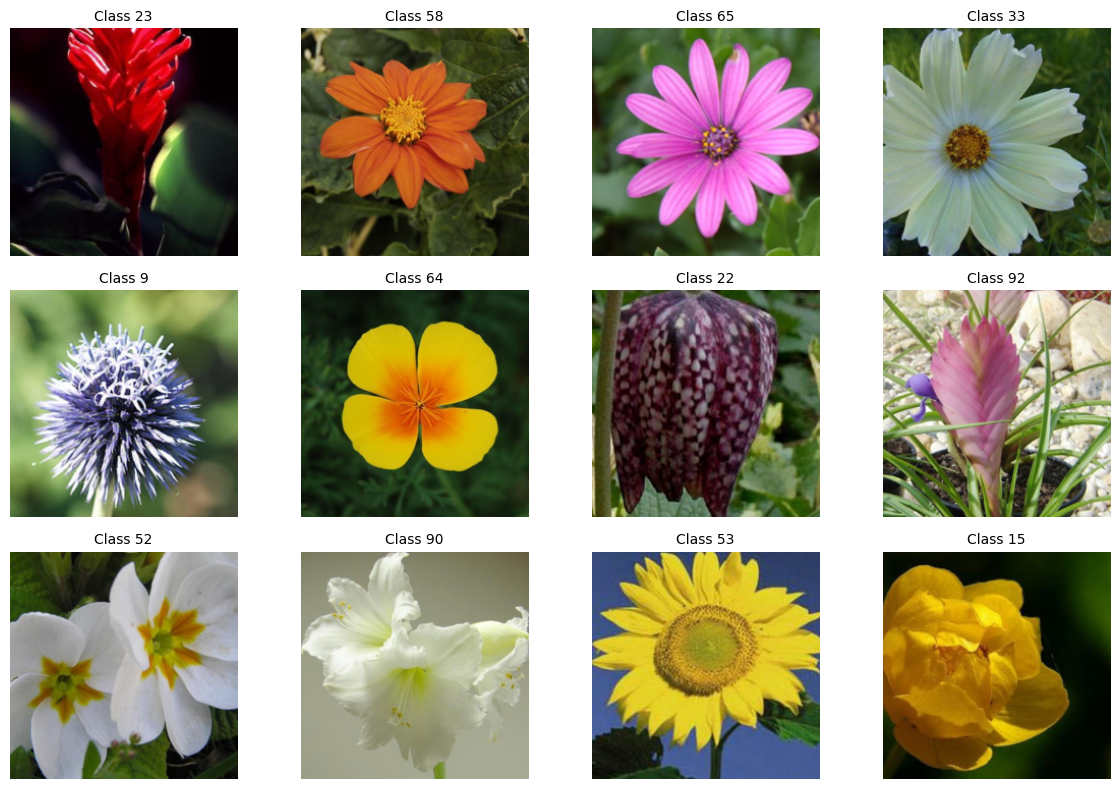

1. 102 Category Flower Dataset: https://www.robots.ox.ac.uk/~vgg/data/flowers/102/
2. CLASS torchvision.datasets.Flowers102: https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Flowers102.html

### 2.0. ハイパーパラメータの設定

演習で使用するパラメータは以下になります。

In [ ]:
# ハイパーパラメータの設定
learning_rate = 0.001 # 学習率
num_classes = 102 # 取り組むタスクのクラス数
batch_size = 64 # バッチサイズ
num_epochs = 10 # エポック数

### 2.1. データセットの準備

- torchvision.datasets.Flowers102 を使用して Oxford Flowers102 データセットをダウンロードし，読み込む。読み込みコードは次のようになる。ここで `train_dataset` が学習セットのデータセット， `test_dataset` がテストセットのデータセットである。
- 授業コンテンツとして提供した CIFAR-10 用のコードに適切な変更を加えてください。

```python
from torchvision.datasets import Flowers102

# データセットとデータローダーの作成 (Flowers102のデータローダーを作成)
def create_dataloaders(batch_size=32):

    ．．．
    # データセットのダウンロードと作成
    train_dataset = Flowers102(root='./data', split='train', download=True, transform=train_transform)
    test_dataset = Flowers102(root='./data', split='test', download=True, transform=test_transform)
    ．．．
```

In [ ]:
from torchvision.datasets import Flowers102

# データセットとデータローダーの作成 (Flowers102のデータローダーを作成)
def create_dataloaders(batch_size=32):

    ．．．

# データローダーの作成
train_loader, test_loader = create_dataloaders(batch_size)

print(f'訓練バッチの数：{len(train_loader)}')
print(f'テストバッチの数：{len(test_loader)}')

### 2.2. 事前学習済みモデルを用いた転移学習

- torchvision.models から事前学習済みの ResNet50 モデルをロードする。
- Oxford Flowers102用に最終層を修正し，転移学習を行う。
- `test_dataset` をモデルへ与えて，正解率を評価する。

In [ ]:
# モデルの作成し、使用可能なデバイスに移動する
．．．

# 学習の実行
．．．

# 学習結果の可視化
．．．

# Flowers102のクラスリストを習得
classes = torchvision.datasets.Flowers102.classes
# テストを実行
．．．

### 2.3. データ拡張の効果を検証

データ拡張（Data Augmentation）および正規化を行い，画像のリサイズ（＝サイズの統一）と ResNet50 の求める画素値の調整を行う。これらは torchvision.transforms.transforms を用いて行う。そのためのコードを次に示す。

```python
import torchvision.transforms as transforms

# データ拡張および正規化
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
```

- torchvision.models から事前学習済みの ResNet50 モデルをロードする。
- 最終層を修正し，転移学習を行えるようモデルを設計する。
- 上記に示すように，訓練データセットに対してデータ拡張を行う。
- `test_dataset` をモデルへ与えて，正解率を評価する。
- さらに，他のデータ拡張を試みる。

In [ ]:
import torchvision.transforms as transforms

# データ拡張および正規化
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# モデルの作成し、使用可能なデバイスに移動する
．．．

# 学習の実行
．．．

# 学習結果の可視化
．．．

# Flowers102のクラスリストを習得
classes = torchvision.datasets.Flowers102.classes
# テストを実行
．．．